#**1.Business understanding**

Business Questions


*   Faktor apa yang paling mempengaruhi keterlambatan delivery?
*   Apakah cuaca dan traffic benar-benar meningkatkan cancellation?

*   Customer seperti apa yang sering meminta refund?

*   Apakah diskon meningkatkan order value atau justru menurunkan profit efficiency?

*   Faktor apa yang paling mempengaruhi rating customer?








In [4]:
# =================================
# DATA MANIPULATION
# =================================
import pandas as pd
import numpy as np

# =================================
# DATA VISUALIZATION
# =================================
import matplotlib.pyplot as plt
import seaborn as sns

# =================================
# MACHINE LEARNING
# =================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    accuracy_score,
    classification_report,
    confusion_matrix
)

# =================================
# WARNING
# =================================
import warnings
warnings.filterwarnings('ignore')

In [5]:
df = pd.read_csv("/content/food_delivery_analytics_cleaned.csv")

In [6]:
df

,order_id,city_tier,customer_age,customer_loyalty_score,order_hour,order_day_of_week,order_month,delivery_distance_km,preparation_time_minutes,delivery_time_minutes,...,final_amount_paid,number_of_items,cancellation_flag,delayed_delivery_flag,refund_flag,promo_code_used,premium_customer_flag,festival_or_weekend_flag,delivery_partner_experience_years,delivery_efficiency_score
0,5a87c6ab-e4a8-44ef-8852-f7a63e3b3943,2,21,4.957522,20,6,6,14.117144,23,76,...,111.563784,4,False,False,True,False,False,True,9,71.1
1,8eab78a5-a5c5-41d7-9a5f-5779ee5f2d3d,1,63,38.744721,0,2,2,9.177354,16,34,...,116.059264,7,False,False,False,True,False,False,12,100.0
2,1338cc5b-e5cf-419f-a7c9-4a2577608715,1,68,45.170997,9,2,11,34.753921,41,152,...,111.708170,12,False,False,False,False,False,False,10,34.4
3,5277f2fb-b1b3-4f58-9975-12f8f1b71421,2,30,10.573003,6,6,5,26.596184,9,93,...,153.301345,7,False,False,False,False,True,True,1,45.0
4,df159a97-3a78-4b08-a524-ec433c75b670,2,60,58.284620,12,1,9,26.204152,49,141,...,111.128807,2,True,False,False,False,False,False,6,25.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,a68deac7-6d77-4bf0-ab31-92c0bb9595af,3,24,42.841817,14,1,11,30.992093,41,110,...,108.314483,9,False,False,False,False,False,False,7,63.2
14996,1be179a4-f546-46df-b6de-2c6bd69eedc8,2,48,42.252577,22,1,4,6.910676,46,68,...,120.328754,6,False,False,True,False,True,False,6,61.0
14997,6cb6bdd5-489e-47a8-93cd-50b90d49db74,2,69,89.348950,6,5,5,0.183208,8,28,...,131.154261,1,False,False,False,False,False,False,11,88.1
14998,f84ea2a5-9cc5-4c78-9844-e418bc86d712,2,27,75.109628,10,4,5,23.820737,53,109,...,100.015600,4,True,False,False,False,False,True,7,44.8


In [7]:
df.columns
df.shape
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 30 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   order_id                           15000 non-null  object 
 1   city_tier                          15000 non-null  int64  
 2   customer_age                       15000 non-null  int64  
 3   customer_loyalty_score             15000 non-null  float64
 4   order_hour                         15000 non-null  int64  
 5   order_day_of_week                  15000 non-null  int64  
 6   order_month                        15000 non-null  int64  
 7   delivery_distance_km               15000 non-null  float64
 8   preparation_time_minutes           15000 non-null  int64  
 9   delivery_time_minutes              15000 non-null  int64  
 10  estimated_delivery_time            15000 non-null  int64  
 11  traffic_level_score                15000 non-null  flo

,city_tier,customer_age,customer_loyalty_score,order_hour,order_day_of_week,order_month,delivery_distance_km,preparation_time_minutes,delivery_time_minutes,estimated_delivery_time,...,delivery_partner_rating,customer_rating,order_value,delivery_fee,discount_amount,tip_amount,final_amount_paid,number_of_items,delivery_partner_experience_years,delivery_efficiency_score
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,...,14850.000000,14850.000000,15000.000000,15000.000000,15000.000000,14850.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,2.253133,46.569667,50.017658,11.470933,3.141933,6.474667,20.133756,32.749667,94.139267,94.140667,...,4.196121,3.993556,113.954265,7.493531,14.932581,12.569739,119.083685,6.489933,8.047600,59.165933
std,0.827951,16.840706,28.771665,6.946134,1.809864,3.454469,11.543488,16.162719,33.597132,32.490455,...,0.391959,0.535016,22.713411,4.352771,8.706253,7.221087,25.798587,3.438123,4.302995,18.102487
min,1.000000,18.000000,0.007172,0.000000,1.000000,1.000000,0.103086,5.000000,10.000000,11.000000,...,2.700000,1.500000,100.000000,0.000432,0.000788,0.000205,72.395550,1.000000,1.000000,1.900000
25%,2.000000,32.000000,25.199828,5.000000,1.000000,3.000000,10.133190,19.000000,68.000000,69.000000,...,3.900000,3.600000,100.000000,3.704018,7.279980,6.396828,101.152407,4.000000,4.000000,46.400000
50%,3.000000,46.000000,50.092268,11.000000,3.000000,7.000000,20.228709,33.000000,95.000000,94.000000,...,4.200000,4.000000,100.000000,7.458605,14.857607,12.629302,113.039544,7.000000,8.000000,59.100000
75%,3.000000,61.000000,74.840432,18.000000,5.000000,9.000000,30.047891,47.000000,120.000000,119.000000,...,4.500000,4.400000,124.153105,11.278689,22.521458,18.848336,130.541371,9.000000,12.000000,72.000000
max,3.000000,75.000000,99.989375,23.000000,6.000000,12.000000,39.998739,60.000000,180.000000,178.000000,...,5.000000,5.000000,215.614574,14.998370,29.999893,24.998828,238.600286,12.000000,15.000000,100.000000


In [8]:
df.isnull().sum()

,0
order_id,0
city_tier,0
customer_age,0
customer_loyalty_score,0
order_hour,0
order_day_of_week,0
order_month,0
delivery_distance_km,0
preparation_time_minutes,0
delivery_time_minutes,0


In [9]:
# =====================================
# HANDLING MISSING VALUES
# =====================================

# Impute delivery partner rating with median
df['delivery_partner_rating'] = df[
    'delivery_partner_rating'
].fillna(
    df['delivery_partner_rating'].median()
)

# Impute customer rating with median
df['customer_rating'] = df[
    'customer_rating'
].fillna(
    df['customer_rating'].median()
)

# Missing tips are assumed as no tip given
df['tip_amount'] = df[
    'tip_amount'
].fillna(0)

In [10]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage[missing_percentage > 0]

,0


In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

categorical_cols = df.select_dtypes(include=['object']).columns

print("Numerical Columns:")
print(numerical_cols)

print("\nCategorical Columns:")
print(categorical_cols)

Numerical Columns:
Index(['city_tier', 'customer_age', 'customer_loyalty_score', 'order_hour',
       'order_day_of_week', 'order_month', 'delivery_distance_km',
       'preparation_time_minutes', 'delivery_time_minutes',
       'estimated_delivery_time', 'traffic_level_score',
       'weather_severity_score', 'restaurant_rating',
       'delivery_partner_rating', 'customer_rating', 'order_value',
       'delivery_fee', 'discount_amount', 'tip_amount', 'final_amount_paid',
       'number_of_items', 'delivery_partner_experience_years',
       'delivery_efficiency_score'],
      dtype='object')

Categorical Columns:
Index(['order_id'], dtype='object')


#2. Exploratory Data Analysis (EDA)

##1. Operational perfomance analysis

###a. Delivery time distribution

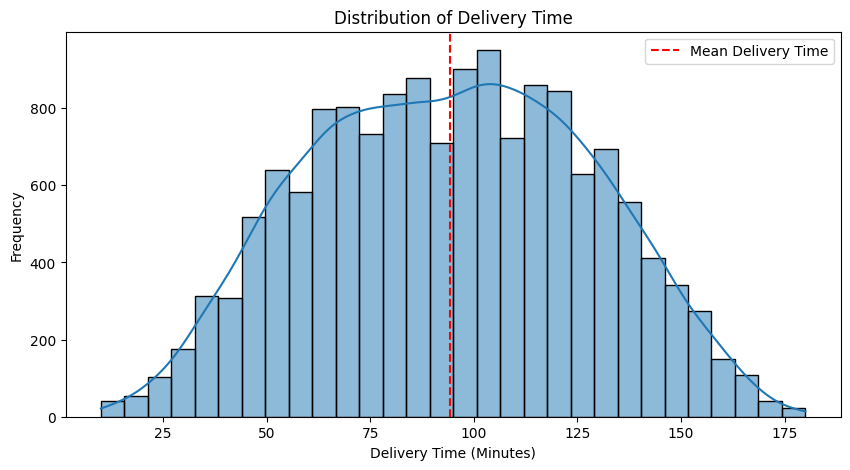

In [13]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x='delivery_time_minutes',
    kde=True,
    bins=30
)

plt.axvline(
    df['delivery_time_minutes'].mean(),
    color='red',
    linestyle='--',
    label='Mean Delivery Time'
)

plt.legend()

plt.title('Distribution of Delivery Time')
plt.xlabel('Delivery Time (Minutes)')
plt.ylabel('Frequency')

plt.show()

###b. Traffic impact analysis

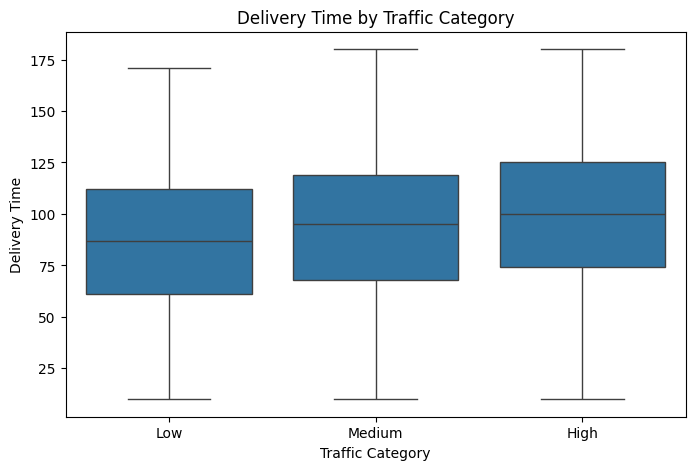

In [14]:
df['traffic_category'] = pd.cut(
    df['traffic_level_score'],
    bins=[0, 3, 6, 10],
    labels=['Low', 'Medium', 'High']
)

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='traffic_category',
    y='delivery_time_minutes'
)

plt.title('Delivery Time by Traffic Category')
plt.xlabel('Traffic Category')
plt.ylabel('Delivery Time')

plt.show()

In [15]:
traffic_analysis = df.groupby('traffic_category')[
    'delivery_time_minutes'
].mean().reset_index()

traffic_analysis

,traffic_category,delivery_time_minutes
0,Low,87.054310
1,Medium,93.796528
2,High,99.864091


###c. Weather saverity impact

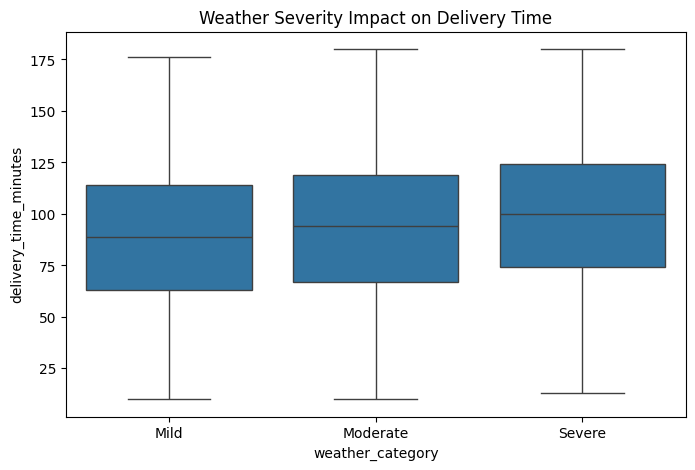

In [16]:
df['weather_category'] = pd.cut(
    df['weather_severity_score'],
    bins=[0, 3, 6, 10],
    labels=['Mild', 'Moderate', 'Severe']
)

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='weather_category',
    y='delivery_time_minutes'
)

plt.title('Weather Severity Impact on Delivery Time')

plt.show()

###d. Peak Hour Operational Bottleneck

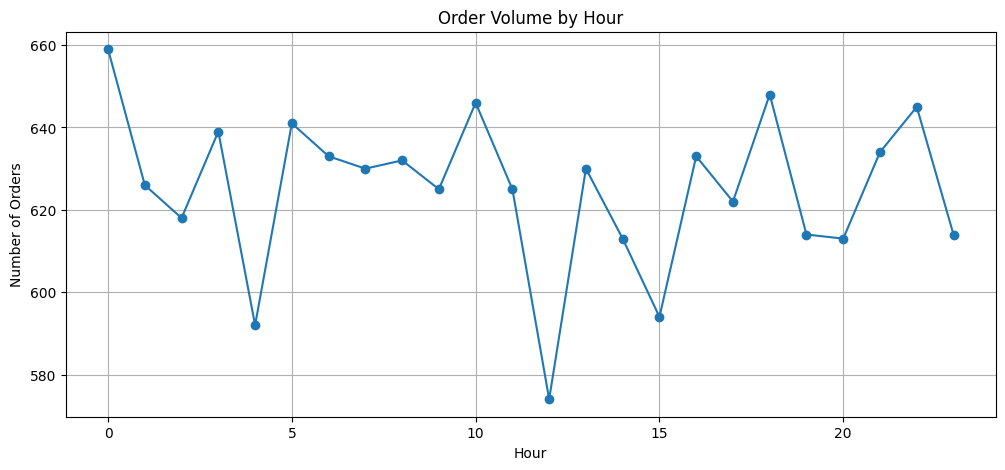

In [17]:
hourly_orders = df.groupby('order_hour').size()

plt.figure(figsize=(12,5))

hourly_orders.plot(marker='o')

plt.title('Order Volume by Hour')
plt.xlabel('Hour')
plt.ylabel('Number of Orders')

plt.grid(True)

plt.show()

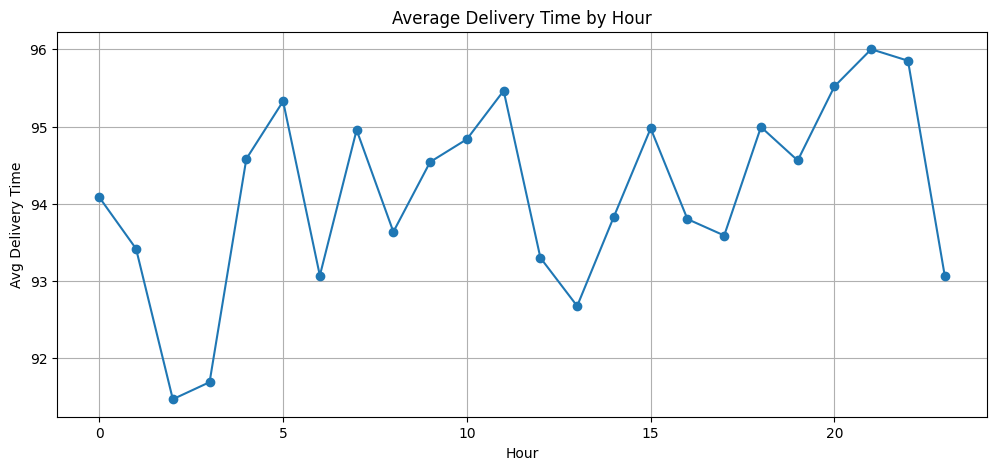

In [18]:
hourly_delivery = df.groupby('order_hour')[
    'delivery_time_minutes'
].mean()

plt.figure(figsize=(12,5))

hourly_delivery.plot(marker='o')

plt.title('Average Delivery Time by Hour')
plt.xlabel('Hour')
plt.ylabel('Avg Delivery Time')

plt.grid(True)

plt.show()

##2. Costumer Rating Distribution

###A. Customer Rating distribution

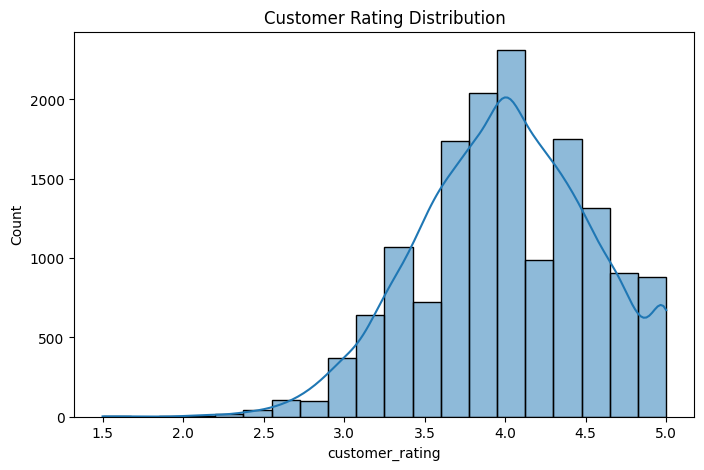

In [19]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['customer_rating'],
    bins=20,
    kde=True
)

plt.title('Customer Rating Distribution')

plt.show()

###B. Delivery time vs customer rating

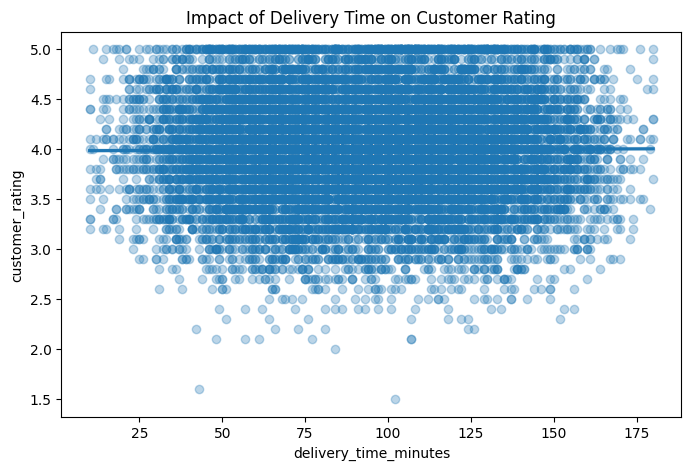

In [20]:
plt.figure(figsize=(8,5))

sns.regplot(
    data=df,
    x='delivery_time_minutes',
    y='customer_rating',
    scatter_kws={'alpha':0.3}
)

plt.title('Impact of Delivery Time on Customer Rating')

plt.show()

###Loyalty analysis

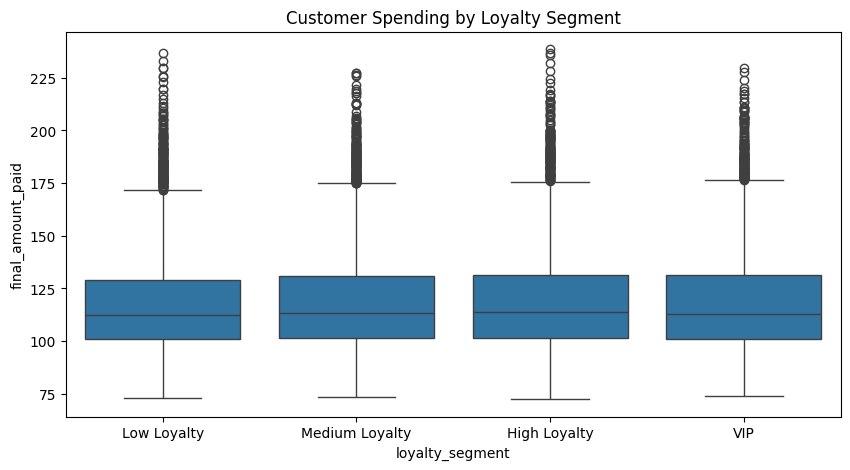

In [21]:
df['loyalty_segment'] = pd.qcut(
    df['customer_loyalty_score'],
    q=4,
    labels=[
        'Low Loyalty',
        'Medium Loyalty',
        'High Loyalty',
        'VIP'
    ]
)

plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x='loyalty_segment',
    y='final_amount_paid'
)

plt.title('Customer Spending by Loyalty Segment')

plt.show()

##Financial analysis

A. Revenue distribution

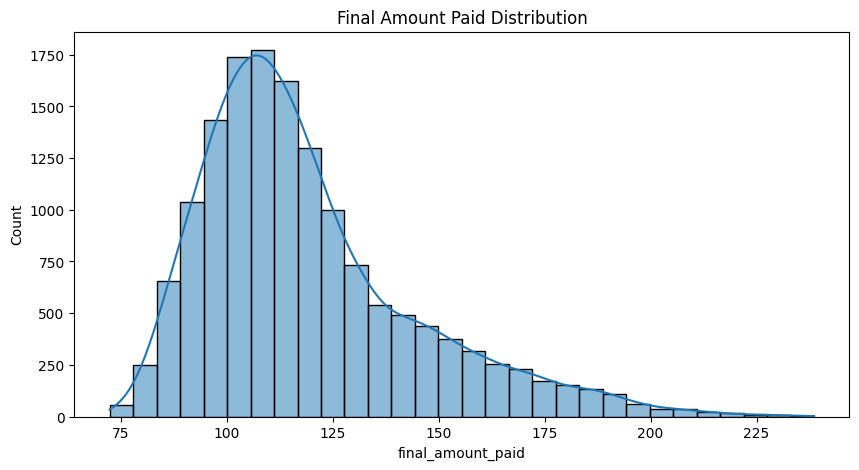

In [22]:
  plt.figure(figsize=(10,5))

sns.histplot(
    df['final_amount_paid'],
    bins=30,
    kde=True
)

plt.title('Final Amount Paid Distribution')

plt.show()

###B. Discount vs Revenue

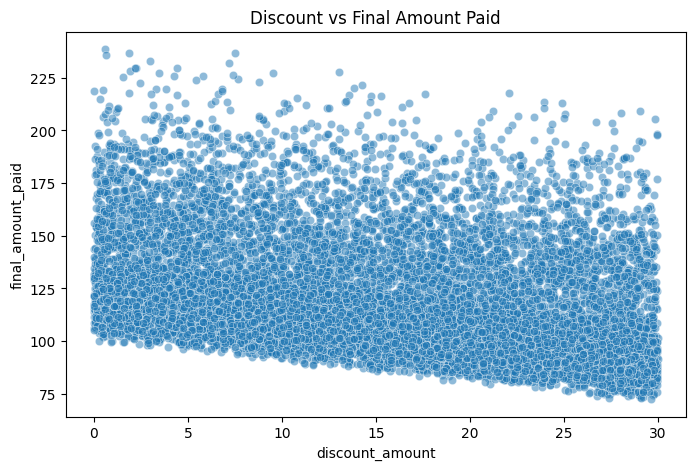

In [23]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='discount_amount',
    y='final_amount_paid',
    alpha=0.5
)

plt.title('Discount vs Final Amount Paid')

plt.show()

###C. Average Order Value by Loyalty Segment

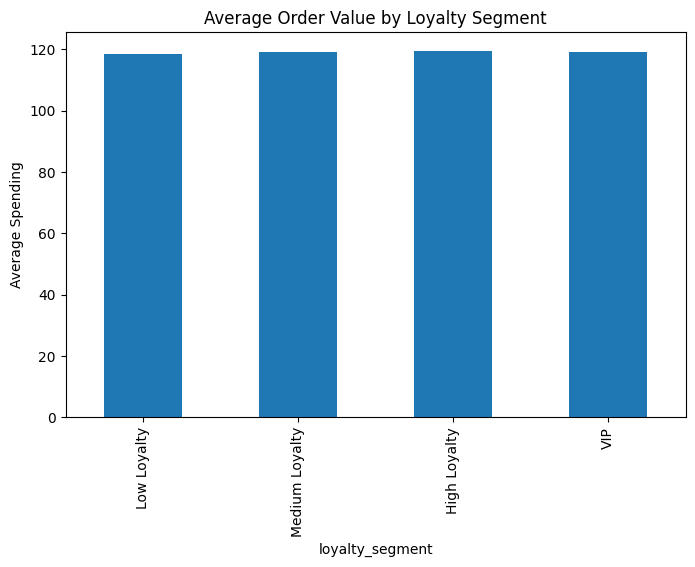

In [24]:
aov = df.groupby('loyalty_segment')[
    'final_amount_paid'
].mean()

aov.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Average Order Value by Loyalty Segment')

plt.ylabel('Average Spending')

plt.show()

##4. DELIVERY PARTNER PERFORMANCE ANALYSIS

###A. Experience vs Efficiency

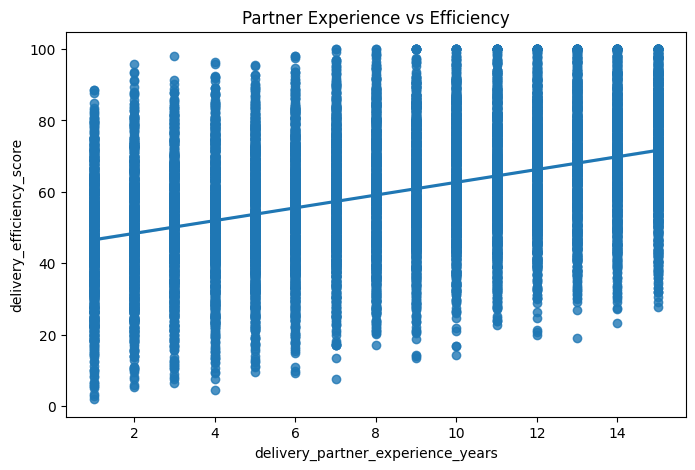

In [25]:
plt.figure(figsize=(8,5))

sns.regplot(
    data=df,
    x='delivery_partner_experience_years',
    y='delivery_efficiency_score'
)

plt.title('Partner Experience vs Efficiency')

plt.show()

INSIGHT : The scatter plot indicates a positive relationshio between delivery partner experience and efficiency score. As experience increases, delivery increases tends to improve. However, the wide dispresion of data points suggest that experience alone does not fully explain delivery perfomance.

###B. Efficiency vs Delivery Time

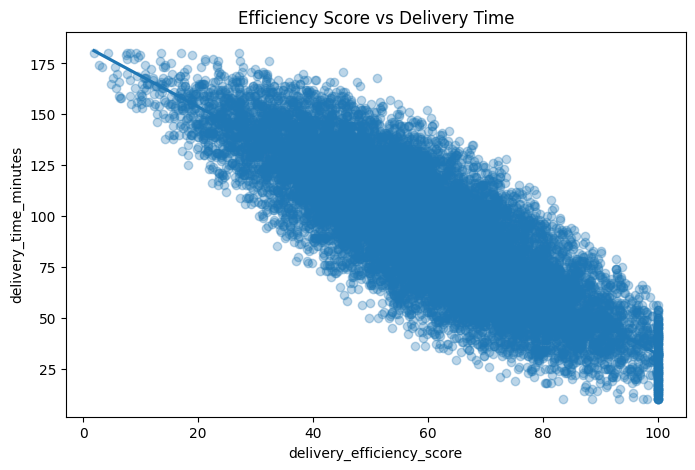

In [26]:
plt.figure(figsize=(8,5))

sns.regplot(
    data=df,
    x='delivery_efficiency_score',
    y='delivery_time_minutes',
    scatter_kws={'alpha':0.3}
)

plt.title('Efficiency Score vs Delivery Time')

plt.show()

INSIGHT : The scatter plot demonstrates a strong negative correlation between delivery efficiency scores and delivery time. Higher efficiency score are associated with shorter delivery duration.

##Corelation matrix

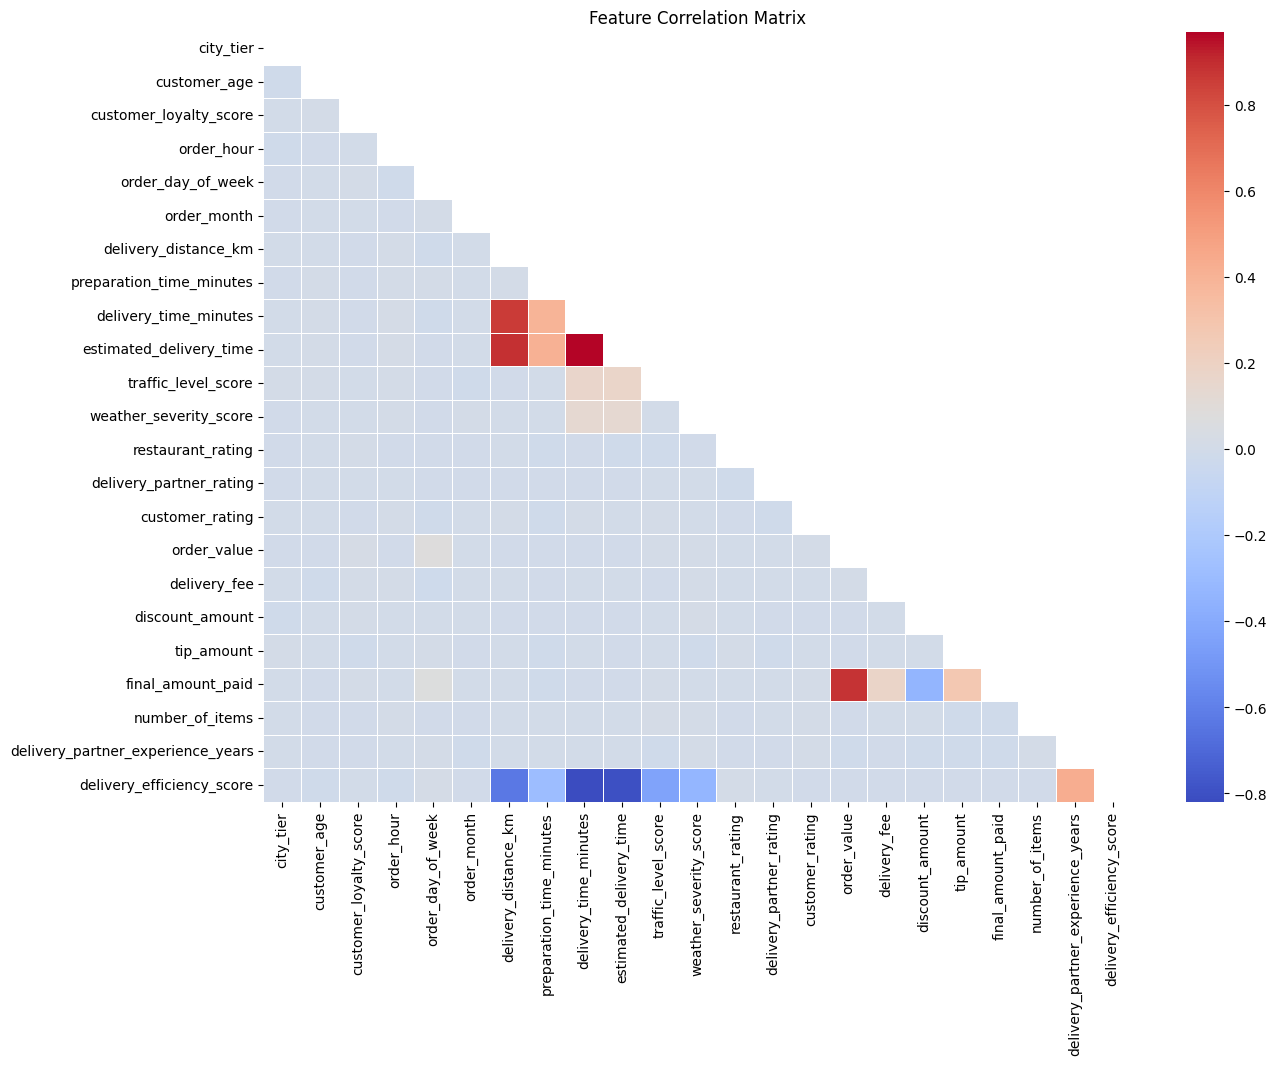

In [66]:
plt.figure(figsize=(14,10))

corr = df[numerical_cols].corr()

mask = np.triu(np.ones_like(corr))

sns.heatmap(
    corr,
    mask=mask,
    annot=False,
    cmap='coolwarm',
    linewidths=0.5
)

plt.title('Feature Correlation Matrix')

plt.show()

INSIGHT : The correlation matrix reveals several meaningful relationship among variables. Delivery efficiency score shows a strong negative correlation eith delivery time, while estimated delivery time is strongly positively correlated with actual delivery duration.

### Top Features Affecting Delivery Time

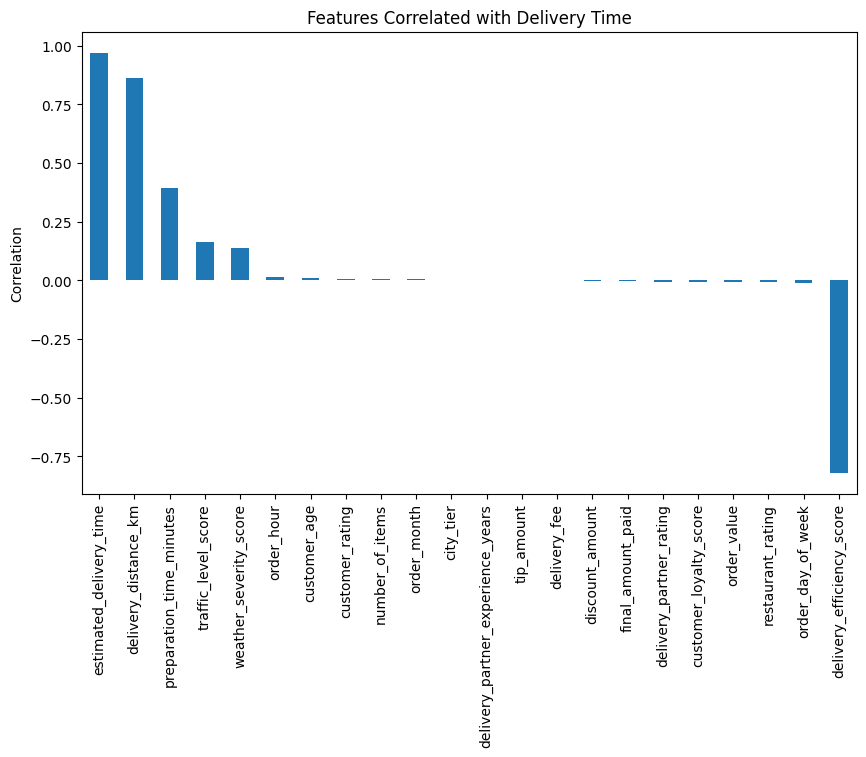

In [28]:
target_corr = corr['delivery_time_minutes'].sort_values(
    ascending=False
)

target_corr = target_corr.drop('delivery_time_minutes')

plt.figure(figsize=(10,6))

target_corr.plot(kind='bar')

plt.title('Features Correlated with Delivery Time')

plt.ylabel('Correlation')

plt.show()

###Pairplot Important Features

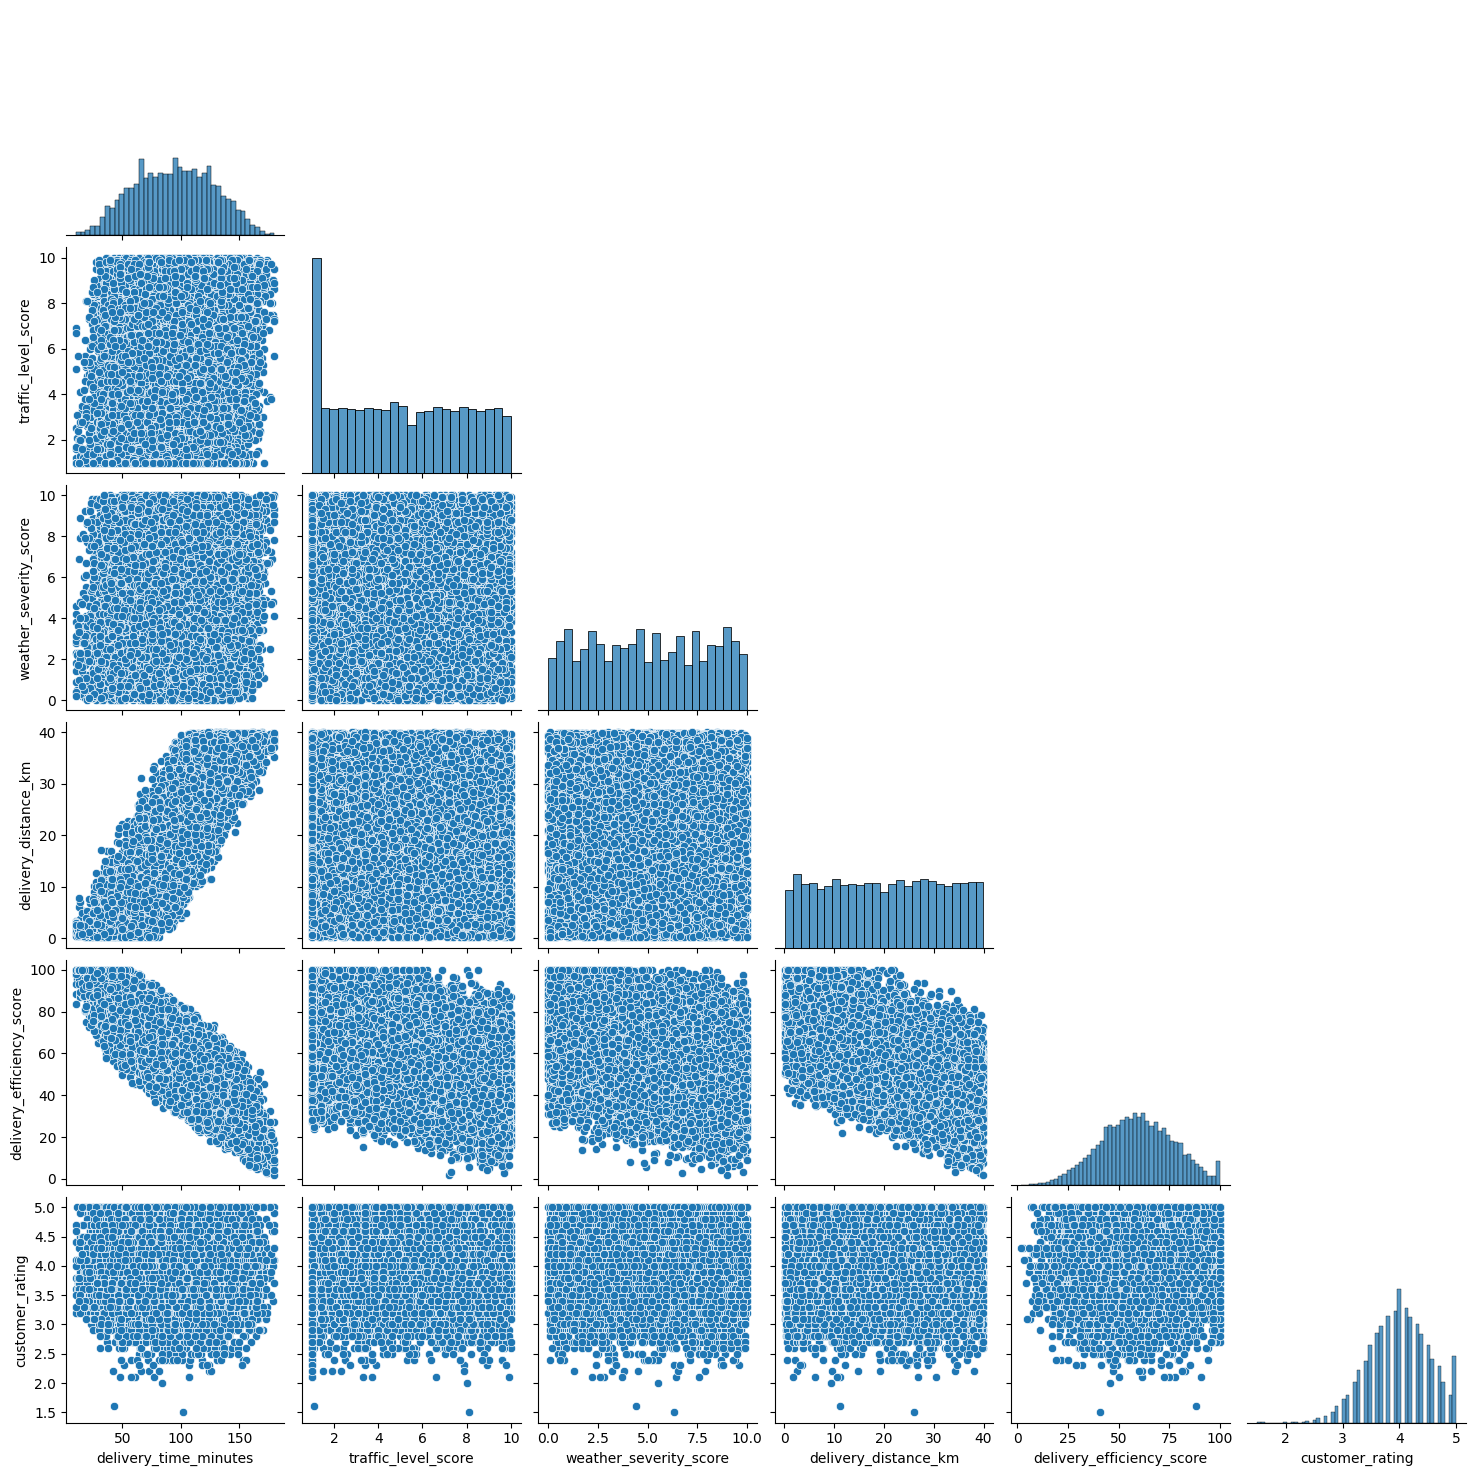

In [29]:
important_features = [
    'delivery_time_minutes',
    'traffic_level_score',
    'weather_severity_score',
    'delivery_distance_km',
    'delivery_efficiency_score',
    'customer_rating'
]

sns.pairplot(
    df[important_features],
    corner=True
)

plt.show()

##Feature Engineering

In [30]:
df_fe = df.copy()

###Peak Hour feature

In [31]:
df_fe['is_peak_hour'] = df_fe['order_hour'].apply(
    lambda x: 1 if (
        (11 <= x <= 14) or
        (18 <= x <= 21)
    ) else 0
)

###Weekend feature

In [32]:
df_fe['is_weekend'] = df_fe[
    'order_day_of_week'
].apply(
    lambda x: 1 if x in [5,6] else 0
)

###High traffic feature

In [33]:
df_fe['high_traffic'] = df_fe[
    'traffic_level_score'
].apply(
    lambda x: 1 if x >= 7 else 0
)

###severe Weather feature

In [34]:
df_fe['severe_weather'] = df_fe[
    'weather_severity_score'
].apply(
    lambda x: 1 if x >= 7 else 0
)

###Delivery speed feature

In [35]:
df_fe['delivery_speed_km_per_min'] = (
    df_fe['delivery_distance_km']
    /
    df_fe['delivery_time_minutes']
)

###Preparation efficiency

In [36]:
df_fe['prep_time_ratio'] = (
    df_fe['preparation_time_minutes']
    /
    df_fe['delivery_time_minutes']
)

###Discount percentage

In [37]:
df_fe['discount_percentage'] = (
    df_fe['discount_amount']
    /
    df_fe['order_value']
) * 100

###Tip percentage

In [38]:
df_fe['tip_percentage'] = (
    df_fe['tip_amount']
    /
    df_fe['final_amount_paid']
) * 100

###Cost per KM

In [39]:
df_fe['delivery_fee_per_km'] = (
    df_fe['delivery_fee']
    /
    df_fe['delivery_distance_km']
)

###Fast delivery feature

In [40]:
median_delivery = df_fe[
    'delivery_time_minutes'
].median()

df_fe['fast_delivery'] = df_fe[
    'delivery_time_minutes'
].apply(
    lambda x: 1 if x <= median_delivery else 0
)

###Customer satisfaction segment

In [41]:
df_fe['high_customer_rating'] = df_fe[
    'customer_rating'
].apply(
    lambda x: 1 if x >= 4 else 0
)

###Traffic & weather interaction

In [42]:
df_fe['traffic_weather_interaction'] = (
    df_fe['traffic_level_score']
    *
    df_fe['weather_severity_score']
)

###Customer value segment

In [43]:
df_fe['customer_value_segment'] = pd.qcut(
    df_fe['final_amount_paid'],
    q=4,
    labels=[
        'Low Value',
        'Medium Value',
        'High Value',
        'Premium'
    ]
)

###Check feature distribution

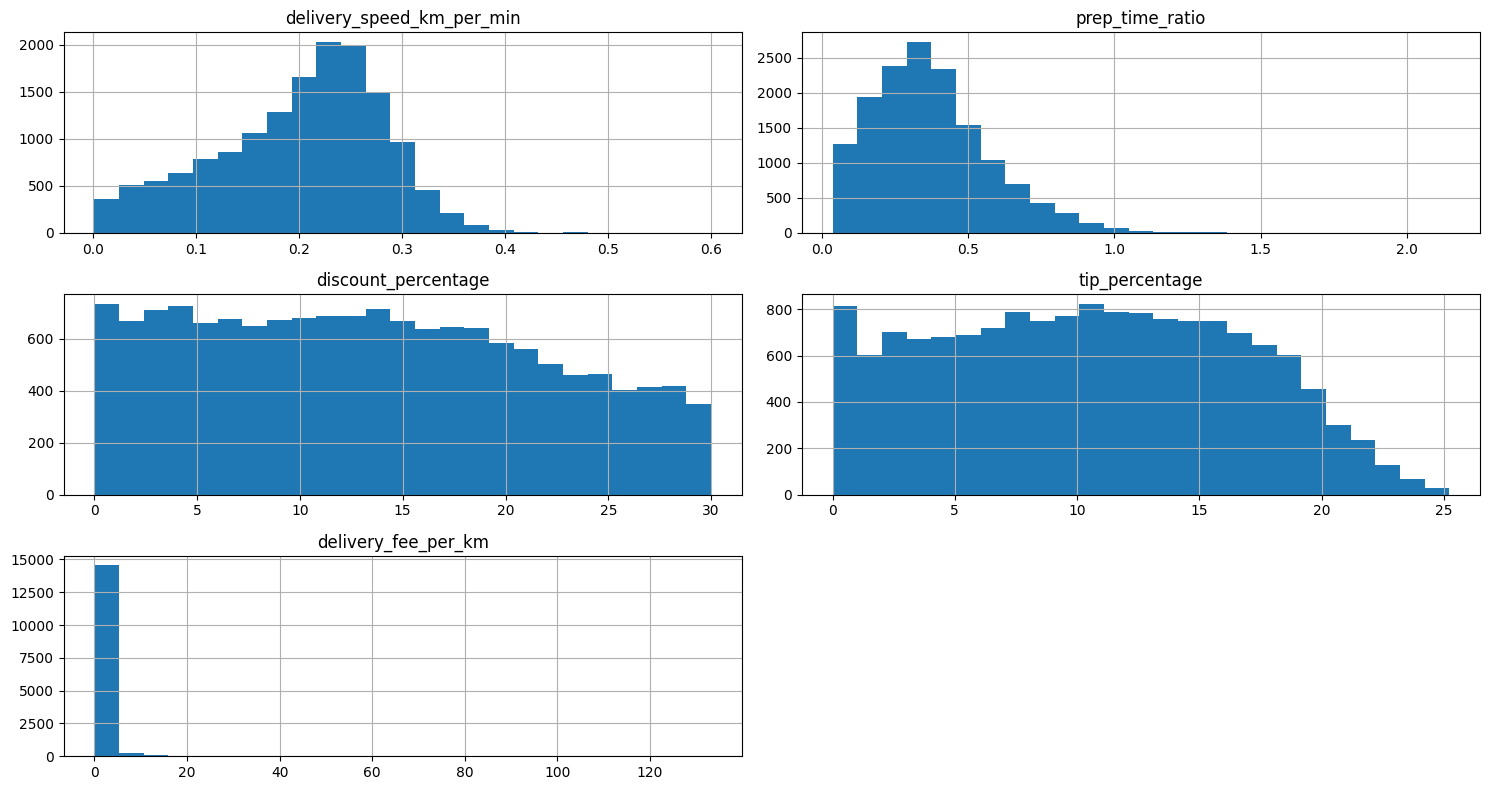

In [44]:
new_features = [
    'delivery_speed_km_per_min',
    'prep_time_ratio',
    'discount_percentage',
    'tip_percentage',
    'delivery_fee_per_km'
]

df_fe[new_features].hist(
    figsize=(15,8),
    bins=25
)

plt.tight_layout()

plt.show()

###Check correlation with target

In [45]:
new_corr = df_fe.corr(numeric_only=True)[
    'delivery_time_minutes'
].sort_values(
    ascending=False
)

new_corr

,delivery_time_minutes
delivery_time_minutes,1.000000
estimated_delivery_time,0.970722
delivery_distance_km,0.863925
delivery_speed_km_per_min,0.477574
preparation_time_minutes,0.394064
traffic_weather_interaction,0.191229
traffic_level_score,0.163487
delayed_delivery_flag,0.157359
weather_severity_score,0.136230
high_traffic,0.130654


###Feature importance preview

In [46]:
from sklearn.ensemble import RandomForestRegressor

X = df_fe.select_dtypes(
    include=['int64','float64']
).drop(
    'delivery_time_minutes',
    axis=1
)

y = df_fe['delivery_time_minutes']

model = RandomForestRegressor(
    random_state=42
)

model.fit(X,y)

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance.head(10)

,Feature,Importance
31,fast_delivery,0.696292
8,estimated_delivery_time,0.251980
26,delivery_speed_km_per_min,0.016344
6,delivery_distance_km,0.010720
27,prep_time_ratio,0.009937
7,preparation_time_minutes,0.004172
21,delivery_efficiency_score,0.001836
33,traffic_weather_interaction,0.001213
9,traffic_level_score,0.000700
20,delivery_partner_experience_years,0.000480


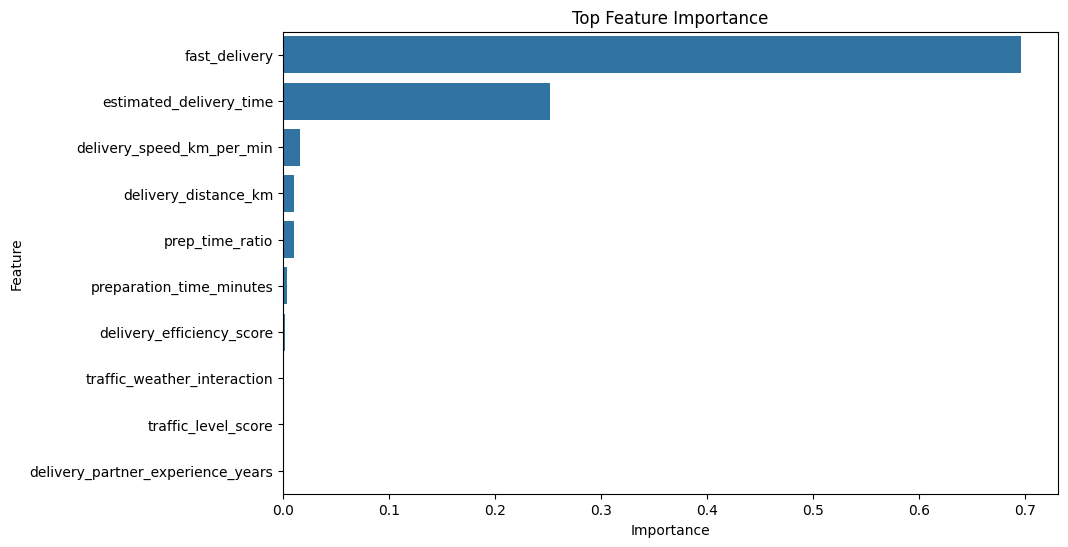

In [47]:
top_features = importance.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_features,
    x='Importance',
    y='Feature'
)

plt.title('Top Feature Importance')

plt.show()

In [67]:
df_fe

,order_id,city_tier,customer_age,customer_loyalty_score,order_hour,order_day_of_week,order_month,delivery_distance_km,preparation_time_minutes,delivery_time_minutes,...,severe_weather,delivery_speed_km_per_min,prep_time_ratio,discount_percentage,tip_percentage,delivery_fee_per_km,fast_delivery,high_customer_rating,traffic_weather_interaction,customer_value_segment
0,5a87c6ab-e4a8-44ef-8852-f7a63e3b3943,2,21,4.957522,20,6,6,14.117144,23,76,...,0,0.185752,0.302632,22.969359,17.873669,1.033680,1,0,14.04,Medium Value
1,8eab78a5-a5c5-41d7-9a5f-5779ee5f2d3d,1,63,38.744721,0,2,2,9.177354,16,34,...,0,0.269922,0.470588,4.434405,13.873903,0.478539,1,0,1.60,High Value
2,1338cc5b-e5cf-419f-a7c9-4a2577608715,1,68,45.170997,9,2,11,34.753921,41,152,...,0,0.228644,0.269737,14.979691,15.828255,0.259148,0,0,34.03,Medium Value
3,5277f2fb-b1b3-4f58-9975-12f8f1b71421,2,30,10.573003,6,6,5,26.596184,9,93,...,1,0.285980,0.096774,10.207906,7.562825,0.428897,1,1,28.16,Premium
4,df159a97-3a78-4b08-a524-ec433c75b670,2,60,58.284620,12,1,9,26.204152,49,141,...,1,0.185845,0.347518,13.716308,11.943692,0.441618,0,1,71.25,Medium Value
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,a68deac7-6d77-4bf0-ab31-92c0bb9595af,3,24,42.841817,14,1,11,30.992093,41,110,...,0,0.281746,0.372727,15.139067,8.806645,0.448975,0,0,2.30,Medium Value
14996,1be179a4-f546-46df-b6de-2c6bd69eedc8,2,48,42.252577,22,1,4,6.910676,46,68,...,1,0.101628,0.676471,16.219022,17.919470,2.168457,1,1,42.56,High Value
14997,6cb6bdd5-489e-47a8-93cd-50b90d49db74,2,69,89.348950,6,5,5,0.183208,8,28,...,0,0.006543,0.285714,10.492367,14.982898,30.353143,1,0,19.55,Premium
14998,f84ea2a5-9cc5-4c78-9844-e418bc86d712,2,27,75.109628,10,4,5,23.820737,53,109,...,0,0.218539,0.486239,28.224098,18.964912,0.389233,0,1,47.57,Low Value


#3. Predictive modeling - Delivery Time Prediction

##Prepare data

In [48]:
df_model = df_fe.copy()

df_model = df_model.drop(
    columns=['order_id'],
    errors='ignore'
)

In [68]:
leakage_features = [
    'fast_delivery',
    'estimated_delivery_time',
    'delayed_delivery_flag'
]

df_model = df_model.drop(
    columns=leakage_features,
    errors='ignore'
)

##Encode categorical Features

In [69]:
df_model = pd.get_dummies(
    df_model,
    drop_first=True
)

##Devine Feature & Target

In [70]:
X = df_model.drop(
    'delivery_time_minutes',
    axis=1
)

y = df_model['delivery_time_minutes']

##Train & Test split

In [71]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

##Baseline model - Linear regression

In [72]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)


##Evaluation Function

In [73]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

def evaluate_model(y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    r2 = r2_score(y_true, y_pred)

    print(f"MAE  : {mae:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"R2   : {r2:.4f}")

    print("Linear Regression Performance")

evaluate_model(y_test, lr_pred)

MAE  : 0.43
RMSE : 1.40
R2   : 0.9983
Linear Regression Performance


##Random forest regressor

In [74]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

##Evaluate random forest

In [75]:
print("Random Forest Performance")

evaluate_model(y_test, rf_pred)

Random Forest Performance
MAE  : 4.94
RMSE : 6.20
R2   : 0.9661
Linear Regression Performance


##Model Comparison

In [76]:
comparison = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest'
    ],
    'MAE': [
        mean_absolute_error(y_test, lr_pred),
        mean_absolute_error(y_test, rf_pred)
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, lr_pred)),
        np.sqrt(mean_squared_error(y_test, rf_pred))
    ],
    'R2': [
        r2_score(y_test, lr_pred),
        r2_score(y_test, rf_pred)
    ]
})

comparison

,Model,MAE,RMSE,R2
0,Linear Regression,0.433123,1.397608,0.998280
1,Random Forest,4.943878,6.203861,0.966117


INSIGHT : Linear Regression outperformed Random Forest, suggesting that delivery duration in the dataset follows a highly linear operational pattern.

This indicates that delivery distance and preparation time are the dominant drivers of delivery duration, with relatively limited nonlinear interactions.

##Feature importance

In [77]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance.head(10)

,Feature,Importance
6,delivery_distance_km,0.691534
25,delivery_efficiency_score,0.173535
7,preparation_time_minutes,0.100375
24,delivery_partner_experience_years,0.020731
34,traffic_weather_interaction,0.002558
8,traffic_level_score,0.000860
2,customer_loyalty_score,0.000741
32,delivery_fee_per_km,0.000670
9,weather_severity_score,0.000653
1,customer_age,0.000622


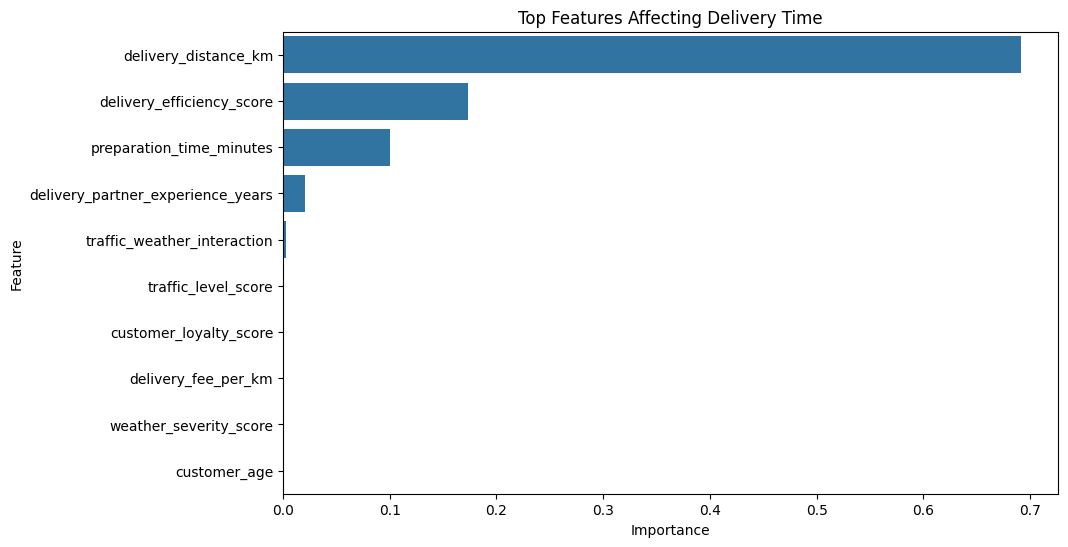

In [78]:
top_features = importance.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_features,
    x='Importance',
    y='Feature'
)

plt.title('Top Features Affecting Delivery Time')

plt.show()

##Actual Vs Prediction

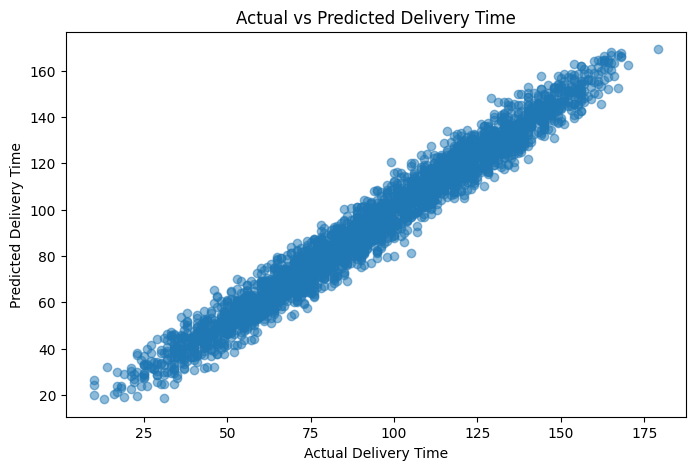

In [79]:
plt.figure(figsize=(8,5))

plt.scatter(
    y_test,
    rf_pred,
    alpha=0.5
)

plt.xlabel('Actual Delivery Time')

plt.ylabel('Predicted Delivery Time')

plt.title('Actual vs Predicted Delivery Time')

plt.show()

##Residual analysis

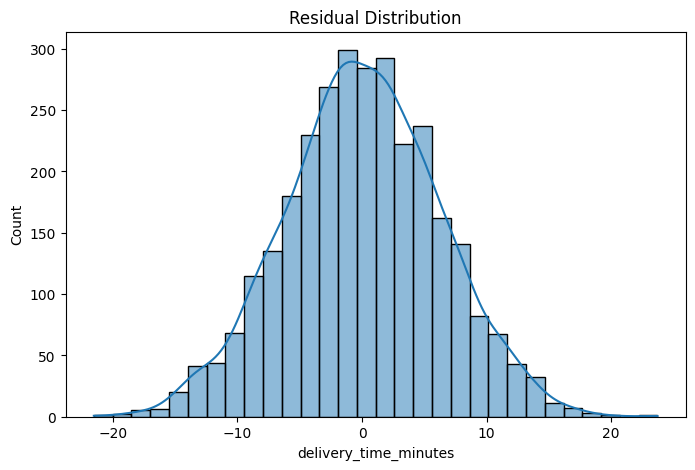

In [80]:
residuals = y_test - rf_pred

plt.figure(figsize=(8,5))

sns.histplot(
    residuals,
    bins=30,
    kde=True
)

plt.title('Residual Distribution')

plt.show()